In [1]:
# Machine Learning Project
# Titanic Survival Prediction
# Universidad Mayor
# Unidad 1 - Fundamentos de Machine Learning
# Alumno: Iván Ramirez Martinez

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [9]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [10]:
df = df.drop(columns=['Cabin'])

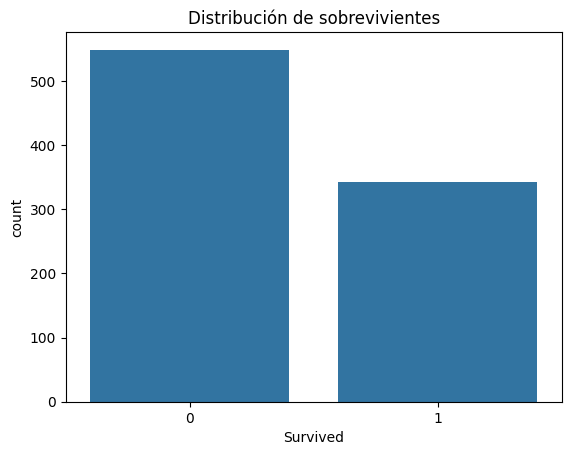

In [11]:
sns.countplot(x="Survived", data=df)
plt.title("Distribución de sobrevivientes")
plt.show()

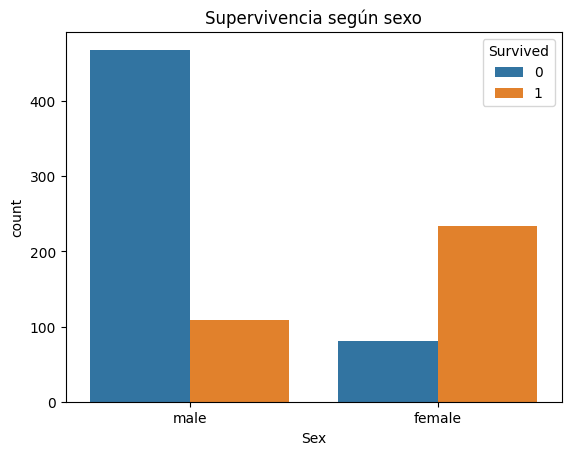

In [12]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Supervivencia según sexo")
plt.show()

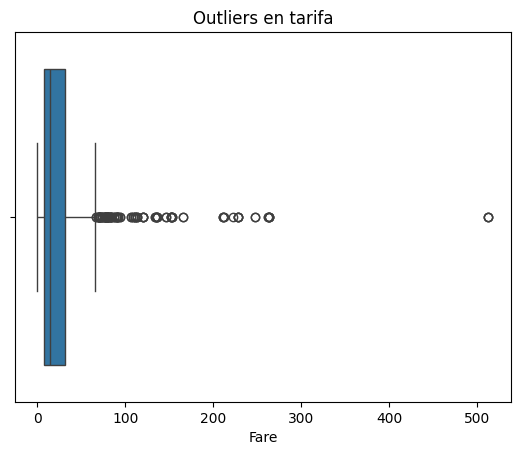

In [13]:
sns.boxplot(x=df["Fare"])
plt.title("Outliers en tarifa")
plt.show()

In [14]:
df = df.drop(columns=["Name","Ticket","PassengerId"])

In [15]:
df = pd.get_dummies(df, drop_first=True)

In [16]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
pred = model.predict(X_test)

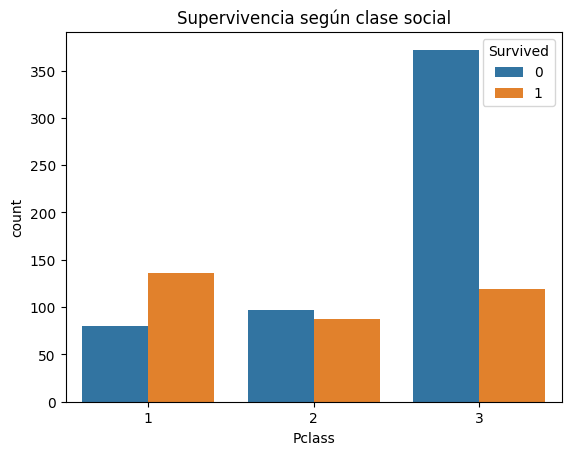

In [20]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Supervivencia según clase social")
plt.show()

In [21]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, pred)

0.8100558659217877

### Análisis del gráfico

El gráfico muestra la relación entre la clase social del pasajero y su probabilidad de supervivencia.

Se observa que los pasajeros de **primera clase** tienen una mayor proporción de sobrevivientes en comparación con los de **tercera clase**, donde la mayoría de los pasajeros no sobrevivió.

Esto sugiere que la posición socioeconómica dentro del barco influyó en las probabilidades de supervivencia durante el desastre del Titanic.


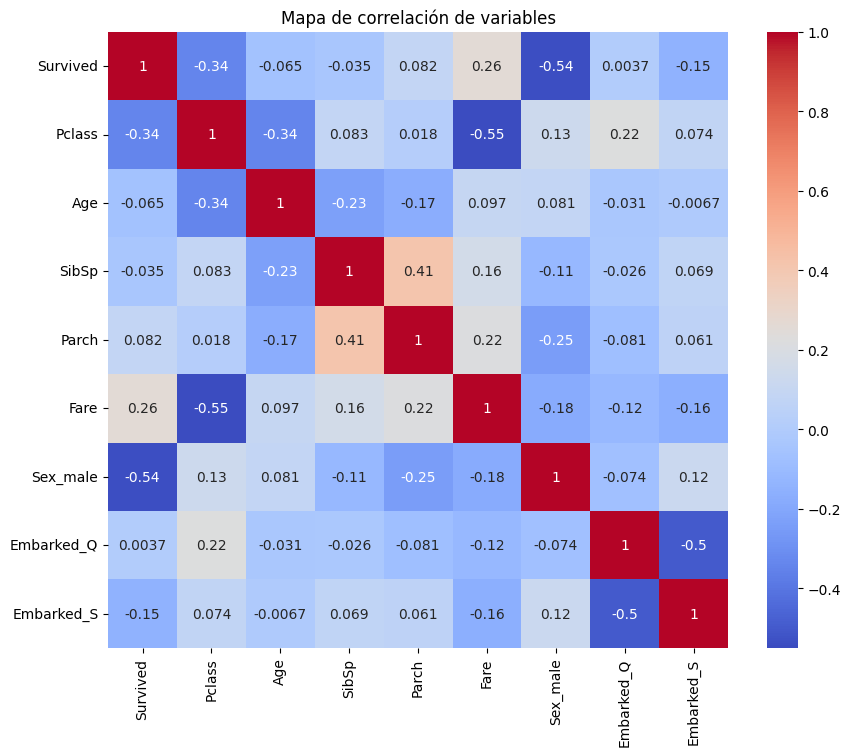

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

correlation = df.corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Mapa de correlación de variables")
plt.show()

### Análisis del mapa de correlación

El mapa de correlación permite identificar la relación entre las variables del dataset. Se observa que variables como el sexo del pasajero y la clase social presentan una relación importante con la variable de supervivencia.

En particular, los pasajeros de primera clase y las mujeres muestran mayores probabilidades de supervivencia, mientras que los pasajeros de tercera clase y los hombres presentan una menor probabilidad de sobrevivir.

Este tipo de análisis permite comprender qué variables tienen mayor influencia en el modelo de predicción.

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Predicciones binarias
pred = model.predict(X_test)

# Probabilidades para AUC
pred_prob = model.predict_proba(X_test)[:, 1]

# Accuracy
acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)

# Matriz de confusión
cm = confusion_matrix(y_test, pred)
print("Matriz de confusión:")
print(cm)

# Precision, Recall, F1-score
print("Reporte de clasificación:")
print(classification_report(y_test, pred))

# AUC
auc = roc_auc_score(y_test, pred_prob)
print("AUC:", auc)

Accuracy: 0.8100558659217877
Matriz de confusión:
[[90 15]
 [19 55]]
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

AUC: 0.8826254826254826


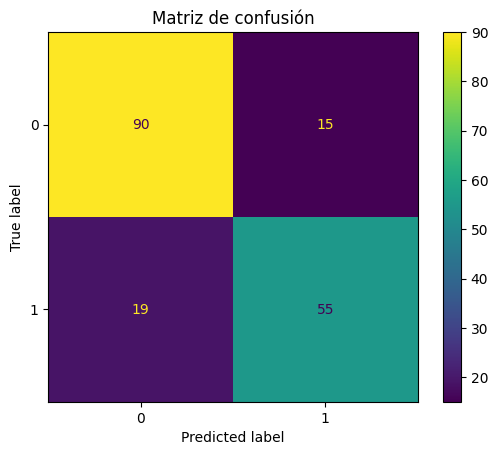

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de confusión")
plt.show()


In [25]:
model.predict_proba(X_test)[:, 1]

array([0.10994346, 0.22216018, 0.13462096, 0.88614912, 0.73602979,
       0.93118158, 0.68373933, 0.09087971, 0.75721169, 0.92174681,
       0.33528191, 0.06957303, 0.38653857, 0.14556437, 0.19792264,
       0.93702818, 0.30185288, 0.6837837 , 0.24517817, 0.33239643,
       0.12100708, 0.40942829, 0.61441475, 0.13501386, 0.11027223,
       0.06878352, 0.46295488, 0.22328158, 0.08148748, 0.59741587,
       0.1382093 , 0.66134004, 0.55618642, 0.6190533 , 0.14193547,
       0.12403905, 0.46010557, 0.68373933, 0.94030279, 0.10860449,
       0.20181262, 0.08068625, 0.10864318, 0.13937468, 0.56813609,
       0.09198872, 0.13829033, 0.12466824, 0.12077417, 0.33344272,
       0.71457036, 0.80932499, 0.04119535, 0.51666781, 0.04971954,
       0.93308888, 0.21692805, 0.93080319, 0.77616225, 0.74004009,
       0.13105872, 0.85854504, 0.76403127, 0.45394907, 0.13937468,
       0.63284041, 0.31334766, 0.10567827, 0.14477493, 0.87128089,
       0.7554466 , 0.94863982, 0.57076423, 0.90148889, 0.12428

In [26]:
from sklearn.metrics import roc_auc_score

pred_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, pred_prob)

print("AUC:", auc)

AUC: 0.8826254826254826
